# Name: Asma I. Punekar
## 02/03/2026

# AIML Capstone :Historical Structures Classification

There are hundreds of years-old historical structures that preserve a country's and community's history for future generations and promote tourism opportunities.
To help the travel and tourism industries, it has been decided to use advanced machine learning techniques to monitor the condition of these historical structures and report to government agencies if any of them need maintenance.
Also, understanding customers (tourists) and their expectations is critical for effective marketing. A recommendation engine is an excellent way to supplement existing


##  1. Import all the datasets and perform preliminary inspections, such as:

1.  Check for missing values and duplicates
2.  Remove any anomalies found in the data





In [1]:
import pandas as pd
import numpy as np


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
import pandas as pd

user_df = pd.read_csv('/content/drive/MyDrive/Task_2/user.csv')
place_df = pd.read_excel('/content/drive/MyDrive/Task_2/tourism_with_id.xlsx')
rating_df = pd.read_csv('/content/drive/MyDrive/Task_2/tourism_rating.csv')


In [4]:
print(user_df.shape)
print(place_df.shape)
print(rating_df.shape)


(300, 3)
(437, 13)
(10000, 3)


In [5]:
user_df.head(2)

,User_Id,Location,Age
0,1,"Semarang, Jawa Tengah",20
1,2,"Bekasi, Jawa Barat",21


In [5]:
user_df['Location'].unique()

array(['Semarang, Jawa Tengah', 'Bekasi, Jawa Barat',
       'Cirebon, Jawa Barat', 'Lampung, Sumatera Selatan',
       'Jakarta Utara, DKI Jakarta', 'Jakarta Selatan, DKI Jakarta',
       'Bandung, Jawa Barat', 'Surabaya, Jawa Timur', 'Yogyakarta, DIY',
       'Bogor, Jawa Barat', 'Depok, Jawa Barat',
       'Jakarta Pusat, DKI Jakarta', 'Jakarta Timur, DKI Jakarta',
       'Subang, Jawa Barat', 'Jakarta Barat, DKI Jakarta',
       'Palembang, Sumatera Selatan', 'Sragen, Jawa Tengah',
       'Ponorogo, Jawa Timur', 'Klaten, Jawa Tengah', 'Solo, Jawa Tengah',
       'Tanggerang, Banten', 'Serang, Banten', 'Cilacap, Jawa Tengah',
       'Kota Gede, DIY', 'Karawang, Jawa Barat', 'Purwakarat, Jawa Barat',
       'Nganjuk, Jawa Timur', 'Madura, Jawa Timur'], dtype=object)

In [6]:
user_df.groupby('User_Id')['Location'].nunique().max()


1

In [7]:
place_df.head(2)

,Place_Id,Place_Name,Description,Category,City,Price,Rating,Time_Minutes,Coordinate,Lat,Long,Unnamed: 11,Unnamed: 12
0,1,Monumen Nasional,Monumen Nasional atau yang populer disingkat d...,Budaya,Jakarta,20000,4.6,15.0,"{'lat': -6.1753924, 'lng': 106.8271528}",-6.175392,106.827153,NaN,1
1,2,Kota Tua,"Kota tua di Jakarta, yang juga bernama Kota Tu...",Budaya,Jakarta,0,4.6,90.0,"{'lat': -6.137644799999999, 'lng': 106.8171245}",-6.137645,106.817125,NaN,2


In [8]:
place_df['City'].unique()

array(['Jakarta', 'Yogyakarta', 'Bandung', 'Semarang', 'Surabaya'],
      dtype=object)

In [ ]:
place_df['Place_Name'].unique()

In [10]:
print("Missing values in user_df:\n", user_df.isnull().sum())


Missing values in user_df:
 User_Id     0
Location    0
Age         0
dtype: int64


In [11]:
print("Missing values in place_df:\n", place_df.isnull().sum())


Missing values in place_df:
 Place_Id          0
Place_Name        0
Description       0
Category          0
City              0
Price             0
Rating            0
Time_Minutes    232
Coordinate        0
Lat               0
Long              0
Unnamed: 11     437
Unnamed: 12       0
dtype: int64


In [13]:
print("Missing values in rating_df:\n", rating_df.isnull().sum())


Missing values in rating_df:
 User_Id          0
Place_Id         0
Place_Ratings    0
dtype: int64


In [14]:
print("Duplicate rows in user_df:", user_df.duplicated().sum())
print("Duplicate rows in place_df:", place_df.duplicated().sum())
print("Duplicate rows in rating_df:", rating_df.duplicated().sum())


Duplicate rows in user_df: 0
Duplicate rows in place_df: 0
Duplicate rows in rating_df: 79


In [15]:
rating_df.drop_duplicates(inplace=True)


In [16]:
place_df.drop(columns=['Unnamed: 11'], inplace=True)


In [17]:
place_df.drop(columns=['Unnamed: 12'], inplace=True)


In [18]:
place_df['Time_Minutes'] = place_df['Time_Minutes'].fillna(
    place_df['Time_Minutes'].median()
)


In [19]:
place_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 437 entries, 0 to 436
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Place_Id      437 non-null    int64  
 1   Place_Name    437 non-null    object 
 2   Description   437 non-null    object 
 3   Category      437 non-null    object 
 4   City          437 non-null    object 
 5   Price         437 non-null    int64  
 6   Rating        437 non-null    float64
 7   Time_Minutes  437 non-null    float64
 8   Coordinate    437 non-null    object 
 9   Lat           437 non-null    float64
 10  Long          437 non-null    float64
dtypes: float64(4), int64(2), object(5)
memory usage: 37.7+ KB


In [20]:
user_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   User_Id   300 non-null    int64 
 1   Location  300 non-null    object
 2   Age       300 non-null    int64 
dtypes: int64(2), object(1)
memory usage: 7.2+ KB


In [21]:
rating_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9921 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   User_Id        9921 non-null   int64
 1   Place_Id       9921 non-null   int64
 2   Place_Ratings  9921 non-null   int64
dtypes: int64(3)
memory usage: 310.0 KB


In [22]:
user_df['Age'].describe()


,Age
count,300.000000
mean,28.700000
std,6.393716
min,18.000000
25%,24.000000
50%,29.000000
75%,34.000000
max,40.000000


In [24]:
rating_df['Place_Ratings'].unique()

array([3, 2, 5, 4, 1])

In [25]:
rating_df = rating_df[
    (rating_df['Place_Ratings'] >= 1) &
    (rating_df['Place_Ratings'] <= 5)
]


In [26]:
place_df['Time_Minutes'].describe()


,Time_Minutes
count,437.000000
mean,70.606407
std,37.889092
min,10.000000
25%,60.000000
50%,60.000000
75%,60.000000
max,360.000000


#2. To understand the tourism highlights better, we should explore the data in depth.
  ## I. Explore the user group that provides the tourism ratings by:


In [29]:
user_rating_df = pd.merge(
    rating_df,
    user_df,
    on='User_Id',
    how='inner'
)

In [30]:
user_rating_df.head()


,User_Id,Place_Id,Place_Ratings,Location,Age
0,1,179,3,"Semarang, Jawa Tengah",20
1,1,344,2,"Semarang, Jawa Tengah",20
2,1,5,5,"Semarang, Jawa Tengah",20
3,1,373,3,"Semarang, Jawa Tengah",20
4,1,101,4,"Semarang, Jawa Tengah",20


## I.1 Analyzing the age distribution of users visiting the places and rating them

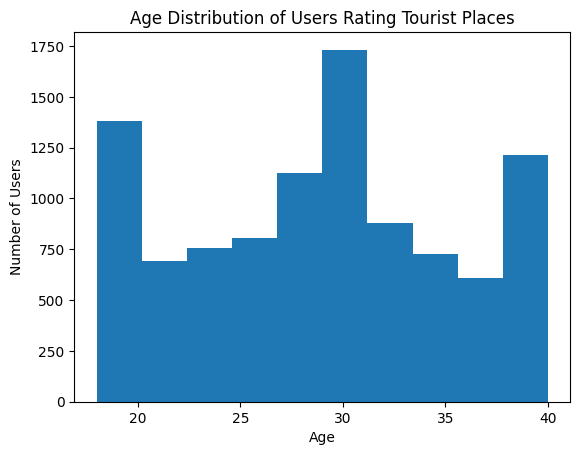

In [31]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(user_rating_df['Age'], bins=10)
plt.xlabel('Age')
plt.ylabel('Number of Users')
plt.title('Age Distribution of Users Rating Tourist Places')
plt.show()


In [32]:
user_rating_df['Age'].describe()


,Age
count,9921.000000
mean,28.728455
std,6.353264
min,18.000000
25%,24.000000
50%,29.000000
75%,34.000000
max,40.000000


In [33]:
user_rating_df['Age'].value_counts().sort_index()


,count
Age,
18,470
19,391
20,519
21,442
22,252
23,360
24,394
25,499
26,309


In [34]:
age_bins = pd.cut(
    user_rating_df['Age'],
    bins=[10, 20, 30, 40, 50, 60, 80]
)

age_bins.value_counts().sort_index()


,count
Age,
"(10, 20]",1380
"(20, 30]",4636
"(30, 40]",3905
"(40, 50]",0
"(50, 60]",0
"(60, 80]",0


## I.2 Identifying the places where most of these users (tourists) are coming from


In [35]:
user_rating_df['Location'].head(2)


,Location
0,"Semarang, Jawa Tengah"
1,"Semarang, Jawa Tengah"


In [36]:
location_counts = user_rating_df['Location'].value_counts()
location_counts.head(10)


,count
Location,
"Bekasi, Jawa Barat",1247
"Semarang, Jawa Tengah",766
"Yogyakarta, DIY",696
"Lampung, Sumatera Selatan",658
"Bogor, Jawa Barat",582
"Cirebon, Jawa Barat",476
"Subang, Jawa Barat",465
"Jakarta Selatan, DKI Jakarta",444
"Depok, Jawa Barat",415


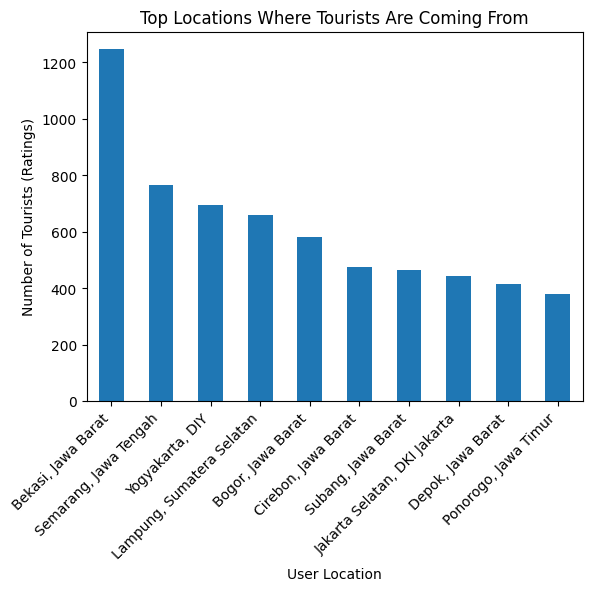

In [37]:
import matplotlib.pyplot as plt

top_locations = location_counts.head(10)

plt.figure()
top_locations.plot(kind='bar')
plt.xlabel('User Location')
plt.ylabel('Number of Tourists (Ratings)')
plt.title('Top Locations Where Tourists Are Coming From')
plt.xticks(rotation=45, ha='right')
plt.show()


In [50]:
user_rating_df['User_City'] = user_rating_df['Location'].str.split(',').str[0]


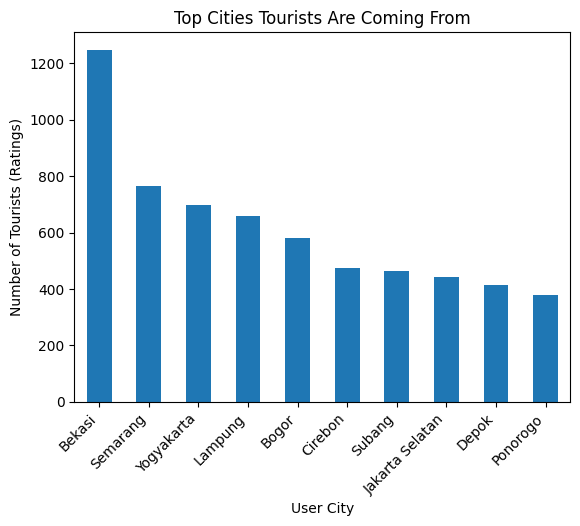

In [51]:
city_counts = user_rating_df['User_City'].value_counts()

plt.figure()
city_counts.head(10).plot(kind='bar')
plt.xlabel('User City')
plt.ylabel('Number of Tourists (Ratings)')
plt.title('Top Cities Tourists Are Coming From')
plt.xticks(rotation=45, ha='right')
plt.show()


##3. Next, let's explore the locations and categories of tourist spots.
## 3.I. What are the different categories of tourist spots?

In [54]:
place_df['Category'].unique()


array(['Budaya', 'Taman Hiburan', 'Cagar Alam', 'Bahari',
       'Pusat Perbelanjaan', 'Tempat Ibadah'], dtype=object)

In [55]:
place_df['Category'].value_counts()


,count
Category,
Taman Hiburan,135
Budaya,117
Cagar Alam,106
Bahari,47
Tempat Ibadah,17
Pusat Perbelanjaan,15


In [ ]:
| **Indonesian Category** | **English Meaning**                   |
| ----------------------- | ------------------------------------- |
| **Taman Hiburan**       | Amusement / Theme Parks               |
| **Budaya**              | Cultural Attractions                  |
| **Cagar Alam**          | Nature Reserves / Natural Attractions |
| **Bahari**              | Marine / Coastal Tourism              |
| **Tempat Ibadah**       | Religious Places                      |
| **Pusat Perbelanjaan**  | Shopping Centers                      |


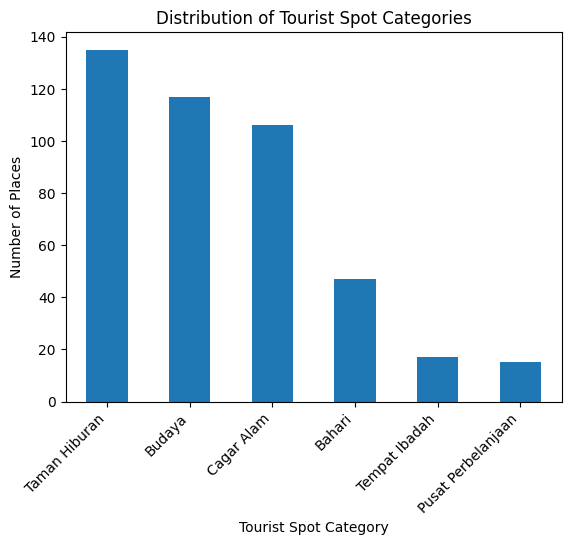

In [56]:
import matplotlib.pyplot as plt

category_counts = place_df['Category'].value_counts()

plt.figure()
category_counts.plot(kind='bar')
plt.xlabel('Tourist Spot Category')
plt.ylabel('Number of Places')
plt.title('Distribution of Tourist Spot Categories')
plt.xticks(rotation=45, ha='right')
plt.show()


In [58]:
place_df.head(2)


,Place_Id,Place_Name,Description,Category,City,Price,Rating,Time_Minutes,Coordinate,Lat,Long
0,1,Monumen Nasional,Monumen Nasional atau yang populer disingkat d...,Budaya,Jakarta,20000,4.6,15.0,"{'lat': -6.1753924, 'lng': 106.8271528}",-6.175392,106.827153
1,2,Kota Tua,"Kota tua di Jakarta, yang juga bernama Kota Tu...",Budaya,Jakarta,0,4.6,90.0,"{'lat': -6.137644799999999, 'lng': 106.8171245}",-6.137645,106.817125


## 3.II. What kind of tourism each location is most famous or suitable for?

In [59]:
city_category_counts = (
    place_df
    .groupby(['City', 'Category'])
    .size()
    .reset_index(name='Place_Count')
)

city_category_counts.head()


,City,Category,Place_Count
0,Bandung,Budaya,22
1,Bandung,Cagar Alam,54
2,Bandung,Pusat Perbelanjaan,1
3,Bandung,Taman Hiburan,39
4,Bandung,Tempat Ibadah,8


In [61]:
dominant_category = (
    city_category_counts
    .sort_values(['City', 'Place_Count'], ascending=[True, False])
    .groupby('City')
    .first()
    .reset_index()
)

dominant_category


,City,Category,Place_Count
0,Bandung,Cagar Alam,54
1,Jakarta,Budaya,32
2,Semarang,Cagar Alam,20
3,Surabaya,Budaya,18
4,Yogyakarta,Taman Hiburan,36


In [ ]:
| **City**       | **Dominant Tourism Type**       | **Number of Places** |
| -------------- | ------------------------------- | -------------------- |
| **Bandung**    | Nature Tourism                  | 54                   |
| **Jakarta**    | Cultural Tourism                | 32                   |
| **Semarang**   | Nature Tourism                  | 20                   |
| **Surabaya**   | Cultural Tourism                | 18                   |
| **Yogyakarta** | Entertainment / Leisure Tourism | 36                   |


## 3.III. Which city would be best for a nature enthusiast to visit?

In [38]:
# Filter only nature-based tourist spots
nature_places = place_df[place_df['Category'] == 'Cagar Alam']

# Count nature places city-wise
nature_city_counts = (
    nature_places
    .groupby('City')
    .size()
    .reset_index(name='Nature_Place_Count')
)

# Sort to find the city with the highest count
nature_city_counts.sort_values(
    by='Nature_Place_Count',
    ascending=False
)


,City,Nature_Place_Count
0,Bandung,54
4,Yogyakarta,23
2,Semarang,20
3,Surabaya,5
1,Jakarta,4


In [39]:
best_city_for_nature = nature_city_counts.loc[
    nature_city_counts['Nature_Place_Count'].idxmax()
]

best_city_for_nature


,0
City,Bandung
Nature_Place_Count,54


## 4. To better understand tourism, we need to create a combined data with places and their user ratings.

In [41]:
place_rating_df = pd.merge(
    rating_df,
    place_df,
    on='Place_Id',
    how='inner'
)


In [66]:
place_rating_df.head(2)


,User_Id,Place_Id,Place_Ratings,Place_Name,Description,Category,City,Price,Rating,Time_Minutes,Coordinate,Lat,Long
0,1,179,3,Candi Ratu Boko,Situs Ratu Baka atau Candi Boko (Hanacaraka:Í¶...,Budaya,Yogyakarta,75000,4.6,90.0,"{'lat': -7.7705416, 'lng': 110.4894158}",-7.770542,110.489416
1,1,344,2,Pantai Marina,Pantai Marina (bahasa Jawa: Í¶•Í¶±Í¶∂Í¶±Í¶∂Í¶Ç...,Bahari,Semarang,3000,4.1,60.0,"{'lat': -6.948877, 'lng': 110.3893285}",-6.948877,110.389329


In [67]:
place_rating_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9921 entries, 0 to 9920
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   User_Id        9921 non-null   int64  
 1   Place_Id       9921 non-null   int64  
 2   Place_Ratings  9921 non-null   int64  
 3   Place_Name     9921 non-null   object 
 4   Description    9921 non-null   object 
 5   Category       9921 non-null   object 
 6   City           9921 non-null   object 
 7   Price          9921 non-null   int64  
 8   Rating         9921 non-null   float64
 9   Time_Minutes   9921 non-null   float64
 10  Coordinate     9921 non-null   object 
 11  Lat            9921 non-null   float64
 12  Long           9921 non-null   float64
dtypes: float64(4), int64(4), object(5)
memory usage: 1007.7+ KB


In [68]:
place_rating_df.shape


(9921, 13)

In [42]:
place_rating_df = place_rating_df[[
    'User_Id',
    'Place_Id',
    'Place_Name',
    'Category',
    'City',
    'Place_Ratings'
]]


In [71]:
place_rating_df.head(2)

,User_Id,Place_Id,Place_Name,Category,City,Place_Ratings
0,1,179,Candi Ratu Boko,Budaya,Yogyakarta,3
1,1,344,Pantai Marina,Bahari,Semarang,2


## 4.I. Use this data to figure out the spots that are most loved by the tourists. Also, which city has the most loved tourist spots?

In [43]:
most_loved_places = (
    place_rating_df
    .groupby('Place_Name')['Place_Ratings']
    .mean()
    .reset_index(name='Avg_Rating')
    .sort_values(by='Avg_Rating', ascending=False)
)

most_loved_places.head(10)


,Place_Name,Avg_Rating
158,Keraton Surabaya,3.933333
312,Puncak Gunung Api Purba - Nglanggeran,3.882353
135,Kampung Cina,3.842105
25,Bukit Jamur,3.793103
402,Teras Cikapundung BBWS,3.789474
23,Bukit Bintang Yogyakarta,3.764706
200,Monumen Yogya Kembali,3.761905
88,Glamping Lakeside Rancabali,3.750000
193,Monumen Nasional,3.722222
249,Pantai Baron,3.695652


In [45]:
most_loved_cities = (
    place_rating_df
    .groupby('City')['Place_Ratings']
    .mean()
    .reset_index(name='Avg_Rating')
    .sort_values(by='Avg_Rating', ascending=False)
)

most_loved_cities


,City,Avg_Rating
4,Yogyakarta,3.104986
0,Bandung,3.079022
3,Surabaya,3.078035
2,Semarang,3.035850
1,Jakarta,3.007361


## 4.II. Indonesia provides a wide range of tourist spots ranging from historical and culturalbeauties to advanced amusement parks. Among these, which category of places are usersliking the most?

In [46]:
category_ratings = (
    place_rating_df
    .groupby('Category')['Place_Ratings']
    .mean()
    .reset_index(name='Avg_Rating')
    .sort_values(by='Avg_Rating', ascending=False)
)

category_ratings


,Category,Avg_Rating
4,Taman Hiburan,3.118386
5,Tempat Ibadah,3.086387
2,Cagar Alam,3.081352
1,Budaya,3.032270
0,Bahari,3.011194
3,Pusat Perbelanjaan,2.947507


In [47]:
most_liked_category = category_ratings.iloc[0]
most_liked_category


,4
Category,Taman Hiburan
Avg_Rating,3.118386


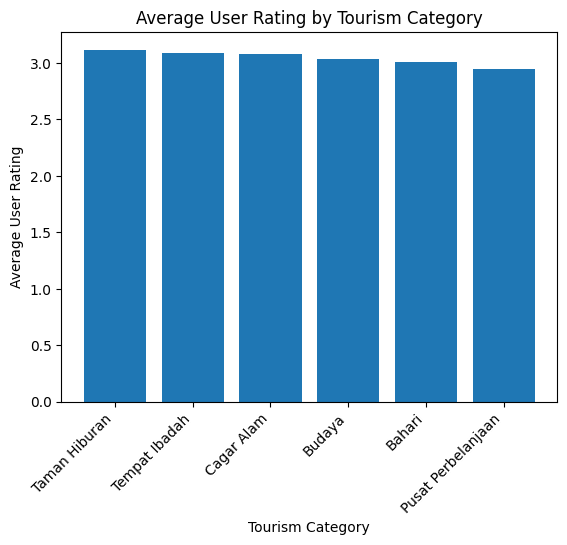

In [50]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(category_ratings['Category'], category_ratings['Avg_Rating'])
plt.xlabel('Tourism Category')
plt.ylabel('Average User Rating')
plt.title('Average User Rating by Tourism Category')
plt.xticks(rotation=45, ha='right')
plt.show()


## 5. Build a recommender model for the system I. Use the above data to develop a collaborative filtering model for recommendation and use that to recommend other places to visit using the current tourist location(place name)

In [49]:
place_rating_df.head()


,User_Id,Place_Id,Place_Name,Category,City,Place_Ratings
0,1,179,Candi Ratu Boko,Budaya,Yogyakarta,3
1,1,344,Pantai Marina,Bahari,Semarang,2
2,1,5,Atlantis Water Adventure,Taman Hiburan,Jakarta,5
3,1,373,Museum Kereta Ambarawa,Budaya,Semarang,3
4,1,101,Kampung Wisata Sosro Menduran,Budaya,Yogyakarta,4


In [57]:
place_rating_df['Place_Name'].value_counts()

,count
Place_Name,
Gunung Lalakon,39
Gereja Perawan Maria Tak Berdosa Surabaya,37
Pantai Parangtritis,37
Taman Sungai Mudal,36
Pantai Kesirat,34
...,...
Kauman Pakualaman Yogyakarta,13
Waterboom PIK (Pantai Indah Kapuk),13
Lereng Anteng Panoramic Coffee Place,13


In [51]:
user_item_matrix = place_rating_df.pivot_table(
    index='User_Id',
    columns='Place_Name',
    values='Place_Ratings'
)


In [52]:
user_item_matrix.head(5)


Place_Name,Air Mancur Menari,Air Terjun Kali Pancur,Air Terjun Kedung Pedut,Air Terjun Semirang,Air Terjun Sri Gethuk,Alive Museum Ancol,Alun Alun Selatan Yogyakarta,Alun-Alun Kota Bandung,Alun-alun Utara Keraton Yogyakarta,Amazing Art World,...,Wisata Alam Wana Wisata Penggaron,Wisata Batu Kuda,Wisata Eling Bening,Wisata Kaliurang,Wisata Kampung Krisan Clapar,Wisata Kraton Jogja,Wisata Kuliner Pecenongan,Wisata Lereng Kelir,Wisata Mangrove Tapak,Wot Batu
User_Id,,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,3.0,NaN,NaN,NaN,NaN,2.0,NaN,3.0
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [53]:
user_item_matrix.fillna(0, inplace=True)


In [54]:
from sklearn.metrics.pairwise import cosine_similarity

place_similarity = cosine_similarity(user_item_matrix.T)


In [56]:
place_similarity_df = pd.DataFrame(
    place_similarity,
    index=user_item_matrix.columns,
    columns=user_item_matrix.columns
)
place_similarity_df.head()

Place_Name,Air Mancur Menari,Air Terjun Kali Pancur,Air Terjun Kedung Pedut,Air Terjun Semirang,Air Terjun Sri Gethuk,Alive Museum Ancol,Alun Alun Selatan Yogyakarta,Alun-Alun Kota Bandung,Alun-alun Utara Keraton Yogyakarta,Amazing Art World,...,Wisata Alam Wana Wisata Penggaron,Wisata Batu Kuda,Wisata Eling Bening,Wisata Kaliurang,Wisata Kampung Krisan Clapar,Wisata Kraton Jogja,Wisata Kuliner Pecenongan,Wisata Lereng Kelir,Wisata Mangrove Tapak,Wot Batu
Place_Name,,,,,,,,,,,,,,,,,,,,,
Air Mancur Menari,1.000000,0.000000,0.096964,0.000000,0.01949,0.000000,0.053606,0.000000,0.000000,0.152254,...,0.000000,0.000000,0.110482,0.111740,0.021363,0.049629,0.131369,0.076108,0.000000,0.000000
Air Terjun Kali Pancur,0.000000,1.000000,0.041091,0.031167,0.03091,0.023378,0.045778,0.072384,0.088857,0.005866,...,0.182770,0.102458,0.109176,0.055962,0.221532,0.000000,0.016723,0.114901,0.041823,0.196703
Air Terjun Kedung Pedut,0.096964,0.041091,1.000000,0.018004,0.03846,0.000000,0.250346,0.058540,0.000000,0.147059,...,0.000000,0.024859,0.052323,0.057445,0.168625,0.073450,0.192732,0.067583,0.101474,0.018716
Air Terjun Semirang,0.000000,0.031167,0.018004,1.000000,0.00000,0.000000,0.105065,0.071610,0.000000,0.223338,...,0.109623,0.000000,0.093546,0.037346,0.010049,0.135694,0.044331,0.030207,0.070552,0.094805
Air Terjun Sri Gethuk,0.019490,0.030910,0.038460,0.000000,1.00000,0.028080,0.170569,0.039222,0.009148,0.018117,...,0.016726,0.000000,0.064527,0.022160,0.042932,0.028051,0.170023,0.050186,0.177619,0.000000


In [60]:
def recommend_places(place_name, top_n=5):
    if place_name not in place_similarity_df.columns:
        return f"'{place_name}' not found in the dataset."

    similarity_scores = (
        place_similarity_df[place_name]
        .sort_values(ascending=False)
    )

    # Remove the same place
    similarity_scores = similarity_scores.drop(place_name)

    # Return top N similar places
    return similarity_scores.head(top_n)


In [61]:
recommend_places('Jakarta Planetarium', top_n=5)


,Jakarta Planetarium
Place_Name,
Museum De Javasche Bank,0.337261
Curug Anom,0.237783
Museum Tekstil,0.233538
Dunia Fantasi,0.231911
Monumen Palagan Ambarawa,0.230648


In [62]:
def recommend_places_with_details(place_name, top_n=5):
    recommendations = recommend_places(place_name, top_n)

    return place_df[
        place_df['Place_Name'].isin(recommendations.index)
    ][['Place_Name', 'City', 'Category', 'Rating']]


In [63]:
recommend_places_with_details('Jakarta Planetarium', 5)


,Place_Name,City,Category,Rating
2,Dunia Fantasi,Jakarta,Taman Hiburan,4.6
59,Museum Tekstil,Jakarta,Budaya,4.5
291,Curug Anom,Bandung,Cagar Alam,4.6
368,Monumen Palagan Ambarawa,Semarang,Budaya,4.4
414,Museum De Javasche Bank,Surabaya,Budaya,4.6
